In [1]:
import torch 
import torch.nn as nn
import torch.nn.functional as F

from dataclasses import dataclass

In [2]:
@dataclass
class NSConfig:
    vocab_size: int = 32_000
    emb_dim: int = 768
    n_layers: int = 12
    n_heads: int = 16  # attn hidden dim = 16 * 64 = 1024
    head_dim: int = 64
    n_kv_heads: int = 2
    context_length: int = 2048
    hidden_dim: int = 2048
    use_cache: bool = True
    device: str = "cuda:0"
    dtype = torch.bfloat16

In [3]:
# 1. Rope

def init_rope(cfg: NSConfig):

    inv_freq = 1.0 / 10000 ** torch.arange(0, cfg.head_dim, 2, dtype=torch.float32, device=cfg.device) / cfg.head_dim

    pos = torch.arange(0, cfg.context_length, dtype=torch.float32, device=cfg.device)

    angles = torch.einsum("i,j -> ij", pos, inv_freq)

    angles = torch.cat([angles, angles], dim=-1)

    cos = angles.cos()
    sin = angles.sin()

    return cos, sin


def rotate_half(x):

    head_dim = x.shape[-1]
    assert head_dim % 2 == 0, "head dim must be even"
    x1, x2 = x[:, :, :, : head_dim // 2], x[:, :, :, head_dim // 2 :]
    return torch.cat([-x2, x1], dim=-1)

def apply_rope(q, k, cos, sin):

    q_rotated = q * cos[None, None, : q.shape[2], :] + rotate_half(q) * sin[None, None, : q.shape[2], :]
    k_rotated = k * cos[None, None, : k.shape[2], :] + rotate_half(k) * sin[None, None, : k.shape[2], :]

    return q_rotated.to(dtype=q.dtype), k_rotated.to(dtype=k.dtype)

# Test

cfg = NSConfig()

cos, sin = init_rope(cfg)

q = torch.randn(1, cfg.n_heads, cfg.context_length, cfg.head_dim, dtype=cfg.dtype)
k = torch.randn(1, cfg.n_heads, cfg.context_length, cfg.head_dim, dtype=cfg.dtype)

q_rotated, k_rotated = apply_rope(q.to(cfg.device), k.to(cfg.device), cos, sin)

In [4]:
class GQAAttention(nn.Module):

    def __init__(self, cfg: NSConfig):
        super().__init__()

        assert cfg.n_heads % cfg.n_kv_heads == 0, "n_heads must be divisible by n_kv_heads"

        self.cfg = cfg
        self.kv_group_size = cfg.n_heads // cfg.n_kv_heads

        self.w_q = nn.Linear(cfg.emb_dim, cfg.n_heads * cfg.head_dim, bias=False, device=cfg.device, dtype=cfg.dtype)
        self.w_k = nn.Linear(cfg.emb_dim, cfg.n_kv_heads * cfg.head_dim, bias=False, device=cfg.device, dtype=cfg.dtype)
        self.w_v = nn.Linear(cfg.emb_dim, cfg.n_kv_heads * cfg.head_dim, bias=False, device=cfg.device, dtype=cfg.dtype)
        self.w_o = nn.Linear(cfg.n_heads * cfg.head_dim, cfg.emb_dim, bias=False, device=cfg.device, dtype=cfg.dtype)

        self.register_buffer("k_cache", None, persistent=False)
        self.register_buffer("v_cache", None, persistent=False)

        self.kv_ptr = 0


    def forward(self, x, cos, sin, use_kv_cache=False):

        bsz, new_tokens, _ = x.shape

        q = self.w_q(x).view(bsz, new_tokens, self.cfg.n_heads, self.cfg.head_dim).transpose(1, 2)
        k = self.w_k(x).view(bsz, new_tokens, self.cfg.n_kv_heads, self.cfg.head_dim).transpose(1, 2)
        v = self.w_v(x).view(bsz, new_tokens, self.cfg.n_kv_heads, self.cfg.head_dim).transpose(1, 2)


        if use_kv_cache:

            if self.k_cache is None:
                all_k = k
                all_v = v
            else:
                all_k = torch.cat([self.k_cache, k], dim=2)
                all_v = torch.cat([self.v_cache, v], dim=2)
                all_k = all_k[:, :, -self.cfg.context_length:, :]
                all_v = all_v[:, :, -self.cfg.context_length:, :]

            self.k_cache = all_k
            self.v_cache = all_v

        else:
            all_k = k
            all_v = v


        all_k = torch.repeat_interleave(all_k, self.kv_group_size, dim=1)
        all_v = torch.repeat_interleave(all_v, self.kv_group_size, dim=1)

        q, all_k = apply_rope(q, all_k, cos, sin)

        q_pos = torch.arange(self.kv_ptr, self.kv_ptr + new_tokens, device=x.device)
        k_pos = torch.arange(0, all_k.size(2), device=x.device)

        mask = q_pos.unsqueeze(1) < k_pos.unsqueeze(0)

        if use_kv_cache:
            self.kv_ptr = self.k_cache.size(2)

        attn = q @ all_k.transpose(-2, -1)

        attn_score = F.softmax(attn.masked_fill_(mask[None, None, :, :], -torch.inf) / self.cfg.head_dim ** 0.5, dim=-1) 


        context_v = attn_score @ all_v

        context_v = context_v.transpose(1, 2).contiguous().view(bsz, new_tokens, self.cfg.n_heads * self.cfg.head_dim)

        return self.w_o(context_v)

    def reset_cache(self):
        self.cache_k, self.cache_v = None, None
        self.kv_ptr = 0

# test

cfg = NSConfig()

use_kv_cache = True

cos, sin = init_rope(cfg)

model = GQAAttention(cfg)

x = torch.randn((5, 4, cfg.emb_dim), device=cfg.device, dtype=cfg.dtype)
model(x, cos, sin, use_kv_cache=use_kv_cache)

for i in range(3):
    print(f"iter {i}")
    x = torch.randn((5, 2, cfg.emb_dim), device=cfg.device, dtype=cfg.dtype)
    model(x, cos, sin, use_kv_cache=use_kv_cache)

iter 0
iter 1
iter 2


In [5]:
class RMSNorm(nn.Module):

    def __init__(self, hidden_dim, cfg: NSConfig, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.w = nn.Parameter(torch.ones(hidden_dim, device=cfg.device, dtype=cfg.dtype))


    def forward(self, x):
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps) 
        x = x / rms 
        return x * self.w


cfg = NSConfig()
rms = RMSNorm(10, cfg)
x = torch.arange(10, dtype=cfg.dtype).reshape(1, 10).to(cfg.device)
y = rms(x)
print(y)

tensor([[0.0000, 0.1875, 0.3750, 0.5625, 0.7500, 0.9375, 1.1250, 1.3125, 1.5000,
         1.6875]], device='cuda:0', dtype=torch.bfloat16,
       grad_fn=<MulBackward0>)


In [6]:
class FeedForward(nn.Module):

    def __init__(self, cfg: NSConfig):
        super().__init__()

        self.fc1 = nn.Linear(cfg.emb_dim, cfg.hidden_dim, bias=False, device=cfg.device, dtype=cfg.dtype)
        self.fc2 = nn.Linear(cfg.emb_dim, cfg.hidden_dim, bias=False, device=cfg.device, dtype=cfg.dtype)
        self.fc3 = nn.Linear(cfg.hidden_dim, cfg.emb_dim, bias=False, device=cfg.device, dtype=cfg.dtype)


    def forward(self, x):

        x1 = self.fc1(x)
        x2 = self.fc2(x)
        x = F.silu(x1) * x2

        return self.fc3(x)

In [7]:
class TransformerBlock(nn.Module):

    def __init__(self, cfg: NSConfig):

        super().__init__()

        self.cfg = cfg

        self.ffn = FeedForward(cfg)

        self.attn = GQAAttention(cfg)

        self.rms_norm1 = RMSNorm(cfg.emb_dim, cfg)
        self.rms_norm2 = RMSNorm(cfg.emb_dim, cfg)

    def forward(self, x, cos, sin):

        shortcut_x = x
        x = self.rms_norm1(x)
        x = self.attn(x, cos, sin)
        x = x + shortcut_x

        shortcut_x = x
        x = self.rms_norm2(x)
        x = self.ffn(x)

        return x + shortcut_x

# test

cfg = NSConfig()

block = TransformerBlock(cfg)

cos, sin = init_rope(cfg)

x = torch.randn((1, 4, cfg.emb_dim), device=cfg.device, dtype=cfg.dtype)
block(x, cos, sin)

tensor([[[-0.0918, -0.7188,  0.2422,  ..., -1.0781, -1.4219, -0.1387],
         [ 0.8789, -1.1016,  0.4922,  ..., -1.3203, -1.6016, -0.8672],
         [ 0.6367,  1.6328, -1.3125,  ..., -1.2891, -0.9180,  1.1094],
         [-0.6836,  0.0532, -0.0840,  ..., -0.0947, -0.7734,  0.0166]]],
       device='cuda:0', dtype=torch.bfloat16, grad_fn=<AddBackward0>)

In [8]:
class NsModel(nn.Module):

    def __init__(self, cfg: NSConfig):

        super().__init__()

        self.cfg = cfg

        self.emb = nn.Embedding(cfg.vocab_size, cfg.emb_dim, dtype=cfg.dtype, device=cfg.device)

        cos, sin = init_rope(cfg)

        self.register_buffer("cos", cos, persistent=False)
        self.register_buffer("sin", sin, persistent=False)

        self.layers = nn.ModuleList([
            TransformerBlock(cfg) for _ in range(cfg.n_layers)
        ])

        self.final_norm = RMSNorm(cfg.emb_dim, cfg)
        self.lm_out = nn.Linear(cfg.emb_dim, cfg.vocab_size, bias=False, dtype=cfg.dtype, device=cfg.device)

    def forward(self, x):

        x = self.emb(x)

        for layer in self.layers:
            x = layer(x, self.cos, self.sin)

        x = self.final_norm(x)

        logits = self.lm_out(x)

        return logits


    def reset_kv_cache(self):
        for blk in self.layers:
            blk.attn.reset_cache()

cfg = NSConfig()

model = NsModel(cfg)

x = torch.ones((2, 2048), device=cfg.device, dtype=torch.long)
model(x).shape

torch.Size([2, 2048, 32000])

In [9]:
import os
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

from typing import Iterator
from torch.utils.data import IterableDataset, get_worker_info
from datasets import load_dataset
from tokenizers import Tokenizer

class FineWebStreamingDataset(IterableDataset):

    def __init__(
        self,
        parquet_path: str,
        tokenizer_path: str,
        context_length: int = 2048,
        shuffle: bool = True,
        shuffle_buffer_size: int = 10_000,
        seed: int = 42
    ):
        super().__init__()

        self.parquet_path = parquet_path
        self.tokenizer_path = tokenizer_path
        self.context_length = context_length
        self.shuffle = shuffle
        self.shuffle_buffer_size = shuffle_buffer_size
        self.seed = seed


    def _create_dataset(self):

        dataset = load_dataset("parquet", data_files=self.parquet_path, split="train", streaming=True)

        if self.shuffle:
            dataset = dataset.shuffle(seed=self.seed, buffer_size=self.shuffle_buffer_size)

        return dataset

    def __iter__(self) -> Iterator[dict]:

        worker_info = get_worker_info()

        if worker_info is None:
            # 单进程
            worker_id = 0
            num_workers = 1
        else:
            worker_id = worker_info.id
            num_workers = worker_info.num_workers

        dataset = self._create_dataset()

        if num_workers > 1:
            dataset = dataset.shard(num_shards=num_workers, index=worker_id)


        tokenizer = Tokenizer.from_file(self.tokenizer_path)
        eos_token_id = tokenizer.token_to_id("<eos>")

        if eos_token_id is None:
            raise ValueError(f"<eos> token not found in tokenizer: {self.tokenizer_path}") 

        buffer = []

        sequence_length = self.context_length + 1

        for row in dataset:
            text = row.get("text")
            if not text:
                continue

            token_ids = tokenizer.encode(text).ids

            if not token_ids:
                continue

            # 档之间加入 EOS, 防止不同 document 无边界地连接
            #
            # 例如：document A <eos> document B <eos>

            token_ids.append(eos_token_id)

            buffer.extend(token_ids)

            while len(buffer) >= sequence_length:

                tokens = buffer[: sequence_length]

                del buffer[: sequence_length]

                input_ids = torch.tensor(tokens[:-1], dtype=torch.long)
                labels = torch.tensor(tokens[1:], dtype=torch.long)

                yield (input_ids, labels)



In [10]:
dataset = load_dataset(
    "parquet",
    data_files=(
        "/home/sllm_scratch/D2L/nsllm/data/"
        "pretrain/general_en/fineweb-6b/"
        "fineweb-6b.parquet"
    ),
    split="train",
    streaming=True,
)

print(dataset)
print("num_shards =", dataset.num_shards)

IterableDataset({
    features: ['text', 'meta', 'id'],
    num_shards: 1
})
num_shards = 1


In [11]:
from torch.utils.data import DataLoader

dataset = FineWebStreamingDataset(
    parquet_path=(
        "/home/sllm_scratch/D2L/nsllm/data/pretrain/general_en/fineweb-6b/fineweb-6b.parquet"
    ),
    tokenizer_path=(
        "/home/sllm_scratch/D2L/nsllm/model/tokenizer.json"
    ),
    context_length=2048,
    shuffle=True,
    shuffle_buffer_size=10_000,
)

loader = DataLoader(
    dataset,
    batch_size=4,
    num_workers=0,
    pin_memory=True
)

for i, (input_ids, labels) in enumerate(loader):
    print(input_ids.shape, labels.shape)
    break

torch.Size([4, 2048]) torch.Size([4, 2048])


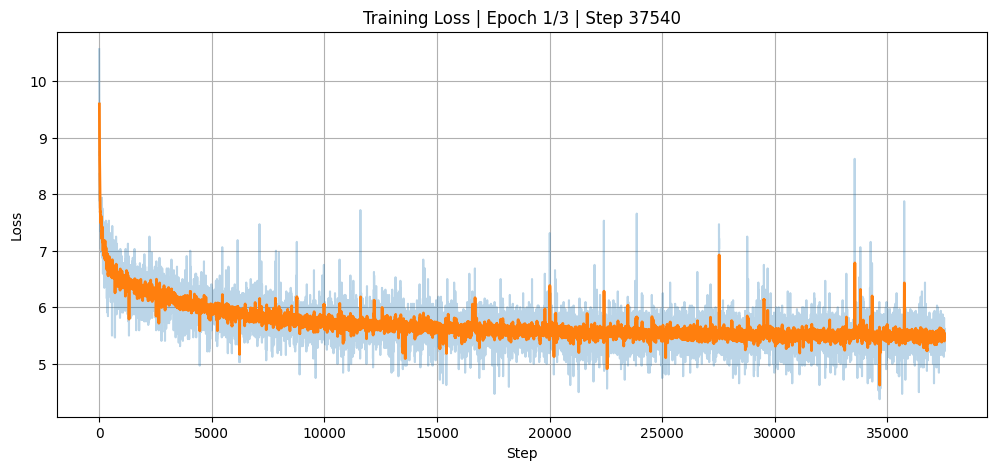

Epoch: 1/3, Step: 37540, Loss: 5.3125


KeyboardInterrupt: 

In [12]:
from IPython.display import clear_output
import matplotlib.pyplot as plt


epochs = 3
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

step = 0

loss_history = []
step_history = []

plot_interval = 10
smooth_window = 10

for epoch in range(epochs):

    for input_ids, labels in loader:

        input_ids = input_ids.to(device=cfg.device)
        labels = labels.to(device=cfg.device)

        
        optimizer.zero_grad()

        logits = model(input_ids)

        logits = logits.view(-1, logits.size(-1))
        labels = labels.view(-1)

        loss = F.cross_entropy(logits, labels)

        loss.backward()
        optimizer.step()

        step += 1

        loss_value = loss.item()

        loss_history.append(loss_value)
        step_history.append(step)

        # =========================
        # 实时绘图
        # =========================

        if step % plot_interval == 0:

            clear_output(wait=True)

            plt.figure(figsize=(12, 5))

            # 原始 Loss
            plt.plot(
                step_history,
                loss_history,
                alpha=0.3,
            )

            # Moving Average
            if len(loss_history) >= smooth_window:

                weights = torch.ones(
                    smooth_window
                ) / smooth_window

                smooth_loss = torch.conv1d(
                    torch.tensor(loss_history)
                    .view(1, 1, -1),
                    weights.view(1, 1, -1),
                ).flatten().numpy()

                smooth_steps = step_history[
                    smooth_window - 1:
                ]

                plt.plot(
                    smooth_steps,
                    smooth_loss,
                    linewidth=2,
                )

            plt.xlabel("Step")
            plt.ylabel("Loss")

            plt.title(
                f"Training Loss | "
                f"Epoch {epoch + 1}/{epochs} | "
                f"Step {step}"
            )

            plt.grid(True)
            plt.show()

            print(
                f"Epoch: {epoch + 1}/{epochs}, "
                f"Step: {step}, "
                f"Loss: {loss_value:.4f}"
            )

In [ ]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
import math

epochs = 3
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)


# ============================================================
# Learning Rate Schedule
# ============================================================

def get_lr(step, max_lr, min_lr, warmup_steps, total_steps):

    # Warmup
    if step < warmup_steps:

        return max_lr * step / warmup_steps

    # Cosine Decay
    progress = (step - warmup_steps) / (total_steps - warmup_steps)

    progress = min(max(progress, 0.0), 1.0)

    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))

    lr = min_lr + (max_lr - min_lr) * cosine
    return lr

min_lr = 3e-5
max_lr = 3e-4
warmup_steps = 1000
max_steps = 500_000


step = 0

loss_history = []
step_history = []
plot_interval = 10
smooth_window = 10



for epoch in range(epochs):

    for input_ids, labels in loader:

        input_ids = input_ids.to(device=cfg.device)
        labels = labels.to(device=cfg.device)

        lr = get_lr(step, max_lr, min_lr, warmup_steps, total_steps=max_steps)
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr
        
        optimizer.zero_grad()

        logits = model(input_ids)

        logits = logits.view(-1, logits.size(-1))
        labels = labels.view(-1)

        loss = F.cross_entropy(logits, labels)

        loss.backward()
        optimizer.step()

        step += 1

        loss_value = loss.item()

        loss_history.append(loss_value)
        step_history.append(step)

        # =========================
        # 实时绘图
        # =========================

        if step % plot_interval == 0:

            clear_output(wait=True)

            plt.figure(figsize=(12, 5))

            # 原始 Loss
            plt.plot(
                step_history,
                loss_history,
                alpha=0.3,
            )

            # Moving Average
            if len(loss_history) >= smooth_window:

                weights = torch.ones(
                    smooth_window
                ) / smooth_window

                smooth_loss = torch.conv1d(
                    torch.tensor(loss_history)
                    .view(1, 1, -1),
                    weights.view(1, 1, -1),
                ).flatten().numpy()

                smooth_steps = step_history[
                    smooth_window - 1:
                ]

                plt.plot(
                    smooth_steps,
                    smooth_loss,
                    linewidth=2,
                )

            plt.xlabel("Step")
            plt.ylabel("Loss")

            plt.title(
                f"Training Loss | "
                f"Epoch {epoch + 1}/{epochs} | "
                f"Step {step}"
            )

            plt.grid(True)
            plt.show()

            print(
                f"Epoch: {epoch + 1}/{epochs}, "
                f"Step: {step}, "
                f"Loss: {loss_value:.4f}"
            )